# English-only BERT Baseline for EWT NER

This notebook replaces a single script with segmented steps.

Goals:
- Train a BERT token-classification baseline on English EWT train data.
- Evaluate on English EWT dev data.
- Export predictions for dev and masked test in project-compatible IOB2 format.

Workflow:
1. Set up environment and imports.
2. Define configuration.
3. Load and validate IOB2 data.
4. Preprocess and build datasets.
5. Implement model/training logic.
6. Run checks and diagnostics.
7. Train and evaluate.
8. Save artifacts for reproducibility.

In [2]:
import json
import os
import random
import subprocess
from collections import Counter
from dataclasses import dataclass
from typing import Dict, List, Sequence, Tuple, Union

import datasets
import matplotlib.pyplot as plt
import numpy as np
import seqeval
import torch
import transformers
from datasets import Dataset
from seqeval.metrics import f1_score, precision_score, recall_score
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Python package versions:")
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("seqeval imported:", hasattr(seqeval, "metrics"))

Python package versions:
torch: 2.11.0
transformers: 5.3.0
datasets: 4.8.4
seqeval imported: True


## 2) Define Configuration and Inputs

This section centralizes paths and training/runtime choices.

You can change model, batch sizes, and epochs without touching later cells.
The defaults are aligned with your baseline script and are safe for local runs.

In [3]:
CONFIG = {
    "train_file": "Datasets/en_ewt-ud-train.iob2",
    "dev_file": "Datasets/en_ewt-ud-dev.iob2",
    "test_file": "Datasets/en_ewt-ud-test-masked.iob2",
    "model_name": "bert-base-cased",
    "output_dir": "outputs/english_bert_baseline_notebook",
    "max_length": 256,
    "learning_rate": 2e-5,
    "train_batch_size": 8,
    "eval_batch_size": 16,
    "gradient_accumulation_steps": 1,
    "num_train_epochs": 4.0,
    "weight_decay": 0.01,
    "fp16": False,
    "seed": 42,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(json.dumps(CONFIG, indent=2))

{
  "train_file": "Datasets/en_ewt-ud-train.iob2",
  "dev_file": "Datasets/en_ewt-ud-dev.iob2",
  "test_file": "Datasets/en_ewt-ud-test-masked.iob2",
  "model_name": "bert-base-cased",
  "output_dir": "outputs/english_bert_baseline_notebook",
  "max_length": 256,
  "learning_rate": 2e-05,
  "train_batch_size": 8,
  "eval_batch_size": 16,
  "gradient_accumulation_steps": 1,
  "num_train_epochs": 4.0,
  "weight_decay": 0.01,
  "fp16": false,
  "seed": 42
}


## 3) Load and Validate Data

Expected schema per token line is tab-separated columns where:
- Column 2 is token text.
- Column 3 is BIO label (for train/dev).

Comment lines starting with `#` are preserved to keep output format compatible with the project scorer.

In [4]:
@dataclass
class SentenceRecord:
    tokens: List[str]
    labels: List[str]
    rows: List[Tuple[str, Union[List[str], str]]]


def read_iob2_file(path: str, use_gold_labels: bool = True) -> List[SentenceRecord]:
    sentences: List[SentenceRecord] = []
    tokens: List[str] = []
    labels: List[str] = []
    rows: List[Tuple[str, Union[List[str], str]]] = []

    def flush_sentence() -> None:
        nonlocal tokens, labels, rows
        if tokens:
            sentences.append(SentenceRecord(tokens=tokens, labels=labels, rows=rows))
        tokens = []
        labels = []
        rows = []

    with open(path, "r", encoding="utf-8") as infile:
        for raw_line in infile:
            line = raw_line.rstrip("\n")
            stripped = line.strip()

            if stripped == "":
                flush_sentence()
                continue

            if stripped.startswith("#") and "\t" not in stripped:
                rows.append(("comment", line))
                continue

            parts = line.split("\t")
            if len(parts) < 2:
                continue

            token = parts[1]
            label = parts[2] if use_gold_labels and len(parts) >= 3 else "O"

            tokens.append(token)
            labels.append(label)
            rows.append(("token", parts))

    flush_sentence()
    return sentences

In [ ]:
train_data = read_iob2_file(CONFIG["train_file"], use_gold_labels=True)
dev_data = read_iob2_file(CONFIG["dev_file"], use_gold_labels=True)
test_data = read_iob2_file(CONFIG["test_file"], use_gold_labels=False)

print("Sentences loaded:")
print("train:", len(train_data))
print("dev:", len(dev_data))
print("test:", len(test_data))

assert len(train_data) > 0 and len(dev_data) > 0 and len(test_data) > 0
assert all(len(s.tokens) == len(s.labels) for s in train_data)
assert all(len(s.tokens) == len(s.labels) for s in dev_data)
assert all(len(s.tokens) == len(s.labels) for s in test_data)

print("Example sentence tokens:", train_data[0].tokens[:12])
print("Example sentence labels:", train_data[0].labels[:12])

## 4) Preprocess Data in Steps

Preprocessing is split to keep each transformation transparent:
- Build a stable label vocabulary.
- Convert sentence objects to Hugging Face datasets.
- Align labels to tokenizer subwords later in a dedicated function.

In [ ]:
def build_label_list(*datasets_: Sequence[SentenceRecord]) -> List[str]:
    labels = set()
    for data in datasets_:
        for sent in data:
            labels.update(sent.labels)
    non_o = sorted(label for label in labels if label != "O")
    return ["O"] + non_o


# Safety guard: if the data-loading cell was not run, load data here.
if "train_data" not in globals() or "dev_data" not in globals() or "test_data" not in globals():
    train_data = read_iob2_file(CONFIG["train_file"], use_gold_labels=True)
    dev_data = read_iob2_file(CONFIG["dev_file"], use_gold_labels=True)
    test_data = read_iob2_file(CONFIG["test_file"], use_gold_labels=False)

label_list = build_label_list(train_data, dev_data)
label_to_id = {label: idx for idx, label in enumerate(label_list)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

print("Label list:", label_list)
print("Data ready:", len(train_data), len(dev_data), len(test_data))

Label list: ['O', 'B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER']
Data ready: 12543 2001 2077


In [7]:
def to_hf_dataset(data: Sequence[SentenceRecord], label_to_id_: Dict[str, int]) -> Dataset:
    return Dataset.from_dict(
        {
            "tokens": [sent.tokens for sent in data],
            "ner_tags": [[label_to_id_[tag] for tag in sent.labels] for sent in data],
        }
    )


train_ds = to_hf_dataset(train_data, label_to_id)
dev_ds = to_hf_dataset(dev_data, label_to_id)
test_ds = to_hf_dataset(test_data, label_to_id)

print(train_ds)
print(dev_ds)
print(test_ds)

Dataset({
    features: ['tokens', 'ner_tags'],
    num_rows: 12543
})
Dataset({
    features: ['tokens', 'ner_tags'],
    num_rows: 2001
})
Dataset({
    features: ['tokens', 'ner_tags'],
    num_rows: 2077
})


## 5) Implement Core Logic in Modular Cells

Each block below has a single responsibility:
- Tokenization and alignment.
- Metrics and decoding.
- Format-preserving prediction export.

This structure makes debugging and ablations easier.

### Tokenization and Label Alignment

BERT splits some words into subword pieces. We attach the NER label to the first subword and mask later subwords with `-100` so they do not contribute to loss.

In [8]:
def tokenize_and_align_labels(examples, tokenizer, max_length: int):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
    )

    aligned_labels = []
    for i, sentence_labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(sentence_labels[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels
    return tokenized_inputs

### Evaluation and Decoding Utilities

`compute_metrics` uses seqeval for NER precision/recall/F1 on valid token positions.
`decode_predictions` maps predicted IDs back to BIO tags while skipping masked positions.

In [9]:
def compute_metrics(eval_preds, id_to_label_: Dict[int, str]):
    predictions, labels = eval_preds
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []
    for pred_seq, label_seq in zip(predictions, labels):
        pred_tags = []
        gold_tags = []
        for pred_id, gold_id in zip(pred_seq, label_seq):
            if gold_id == -100:
                continue
            pred_tags.append(id_to_label_[int(pred_id)])
            gold_tags.append(id_to_label_[int(gold_id)])
        true_predictions.append(pred_tags)
        true_labels.append(gold_tags)

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }


def decode_predictions(predictions: np.ndarray, label_ids: np.ndarray, id_to_label_: Dict[int, str]) -> List[List[str]]:
    pred_ids = np.argmax(predictions, axis=2)
    decoded = []
    for pred_seq, label_seq in zip(pred_ids, label_ids):
        tags = []
        for pred_id, gold_id in zip(pred_seq, label_seq):
            if gold_id == -100:
                continue
            tags.append(id_to_label_[int(pred_id)])
        decoded.append(tags)
    return decoded

### Format-preserving Prediction Writer

This writer keeps comments and row structure from the source files and only replaces column 3 with predicted labels, so output remains compatible with the project scorer.

In [10]:
def write_predictions_iob2(
    source_sentences: Sequence[SentenceRecord],
    predicted_labels: Sequence[Sequence[str]],
    output_path: str,
) -> None:
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, "w", encoding="utf-8") as outfile:
        for sent, pred in zip(source_sentences, predicted_labels):
            token_count = len(sent.tokens)
            pred_list = list(pred)

            if len(pred_list) < token_count:
                pred_list.extend(["O"] * (token_count - len(pred_list)))
            elif len(pred_list) > token_count:
                pred_list = pred_list[:token_count]

            token_idx = 0
            for row_type, row_value in sent.rows:
                if row_type == "comment":
                    outfile.write(str(row_value) + "\n")
                    continue

                parts = list(row_value)
                while len(parts) < 3:
                    parts.append("-")

                parts[2] = pred_list[token_idx]
                token_idx += 1
                outfile.write("\t".join(parts) + "\n")

            outfile.write("\n")

## 6) Run Intermediate Checks and Visualizations

Before training, we check label balance to catch data issues and understand class skew.

Top labels: [('O', 194219), ('B-PER', 2874), ('B-LOC', 2712), ('B-ORG', 1436), ('I-PER', 1294), ('I-ORG', 1167), ('I-LOC', 877)]


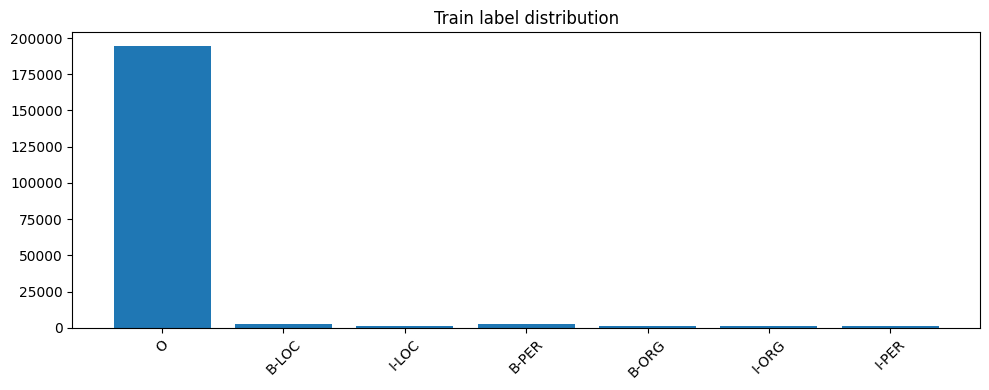

In [11]:
label_counter = Counter(tag for sent in train_data for tag in sent.labels)
print("Top labels:", label_counter.most_common())

labels_for_plot = list(label_counter.keys())
values_for_plot = [label_counter[k] for k in labels_for_plot]

plt.figure(figsize=(10, 4))
plt.bar(labels_for_plot, values_for_plot)
plt.title("Train label distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7) Execute Main Pipeline

Execution order:
1. Initialize tokenizer and tokenize datasets.
2. Create model, data collator, and Trainer.
3. Fit model and evaluate on dev.

In [14]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

tokenized_train = train_ds.map(
    lambda batch: tokenize_and_align_labels(batch, tokenizer, CONFIG["max_length"]),
    batched=True,
)
tokenized_dev = dev_ds.map(
    lambda batch: tokenize_and_align_labels(batch, tokenizer, CONFIG["max_length"]),
    batched=True,
)
tokenized_test = test_ds.map(
    lambda batch: tokenize_and_align_labels(batch, tokenizer, CONFIG["max_length"]),
    batched=True,
)

model = AutoModelForTokenClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=len(label_list),
    id2label=id_to_label,
    label2id=label_to_id,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    learning_rate=CONFIG["learning_rate"],
    per_device_train_batch_size=CONFIG["train_batch_size"],
    per_device_eval_batch_size=CONFIG["eval_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    num_train_epochs=CONFIG["num_train_epochs"],
    weight_decay=CONFIG["weight_decay"],
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",
    fp16=CONFIG["fp16"],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=lambda preds: compute_metrics(preds, id_to_label),
)

print("Trainer initialized. Ready to train.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9664.86it/s]
BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expec

Trainer initialized. Ready to train.


In [15]:
train_result = trainer.train()
dev_metrics = trainer.evaluate()

print("Train result:", train_result)
print("Dev metrics:", dev_metrics)
print("Best checkpoint:", trainer.state.best_model_checkpoint)

/opt/anaconda3/envs/nlp-project-bert/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## 8) Evaluate Results with Metrics

For sequence labeling, we use span-aware precision/recall/F1 via seqeval and the course scorer.

The harmonic mean is:
$$F_1 = 2 \cdot \frac{P \cdot R}{P + R}$$

where $P$ is precision and $R$ is recall.

In [ ]:
# Optional: run project scorer on dev predictions after export (cell 9).
# This uses span_f1.py for strict and loose span metrics.

def run_span_f1(gold_path: str, pred_path: str):
    cmd = ["python", "span_f1.py", gold_path, pred_path]
    completed = subprocess.run(cmd, capture_output=True, text=True)
    print(completed.stdout)
    if completed.returncode != 0:
        print(completed.stderr)

print("Ready to run span_f1 after prediction files are saved.")

## 9) Save Outputs and Export Artifacts

This cell writes:
- `dev_metrics.json`
- `dev_predictions.iob2`
- `test_predictions.iob2`

All files are saved under `outputs/english_bert_baseline_notebook/`.

In [ ]:
metrics_path = os.path.join(CONFIG["output_dir"], "dev_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(dev_metrics, f, indent=2)

dev_pred = trainer.predict(tokenized_dev)
decoded_dev = decode_predictions(dev_pred.predictions, dev_pred.label_ids, id_to_label)
dev_pred_path = os.path.join(CONFIG["output_dir"], "dev_predictions.iob2")
write_predictions_iob2(dev_data, decoded_dev, dev_pred_path)

test_pred = trainer.predict(tokenized_test)
decoded_test = decode_predictions(test_pred.predictions, test_pred.label_ids, id_to_label)
test_pred_path = os.path.join(CONFIG["output_dir"], "test_predictions.iob2")
write_predictions_iob2(test_data, decoded_test, test_pred_path)

print("Saved:", metrics_path)
print("Saved:", dev_pred_path)
print("Saved:", test_pred_path)

# Run official project scorer on dev predictions.
run_span_f1(CONFIG["dev_file"], dev_pred_path)

### HPC / University server tips

- For faster training, increase `train_batch_size` and set `fp16=True` in `CONFIG`.
- For cross-lingual continuation later, switch `model_name` to `bert-base-multilingual-cased`.
- Keep seeds fixed for reproducibility across local and server runs.